In [1]:
! pip install pandas
! pip install numpy
! pip install matplotlib
! pip install seaborn
! pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

### 1. LOADING DATASET


In [3]:
df = pd.read_csv(r"C:\Users\Saran\OneDrive\Desktop\FLIGHT DARE PREDICTION.csv")

In [5]:
print("Rows:", df.shape[0], " | Columns:", df.shape[1])

Rows: 10683  | Columns: 11


In [6]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24-03-2019,Banglore,New Delhi,BLR ? DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897
1,Air India,01-05-2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,09-06-2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,10-06-2026 04:25,19h,2 stops,No info,13882
3,IndiGo,12-05-2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01-03-2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [7]:
print(df['Price'].describe().round(0))
print()
print("Missing values:", df.isnull().sum().sum())

count    10683.0
mean      9087.0
std       4611.0
min       1759.0
25%       5277.0
50%       8372.0
75%      12373.0
max      79512.0
Name: Price, dtype: float64

Missing values: 2


### 2.VISUALISING THE DATA

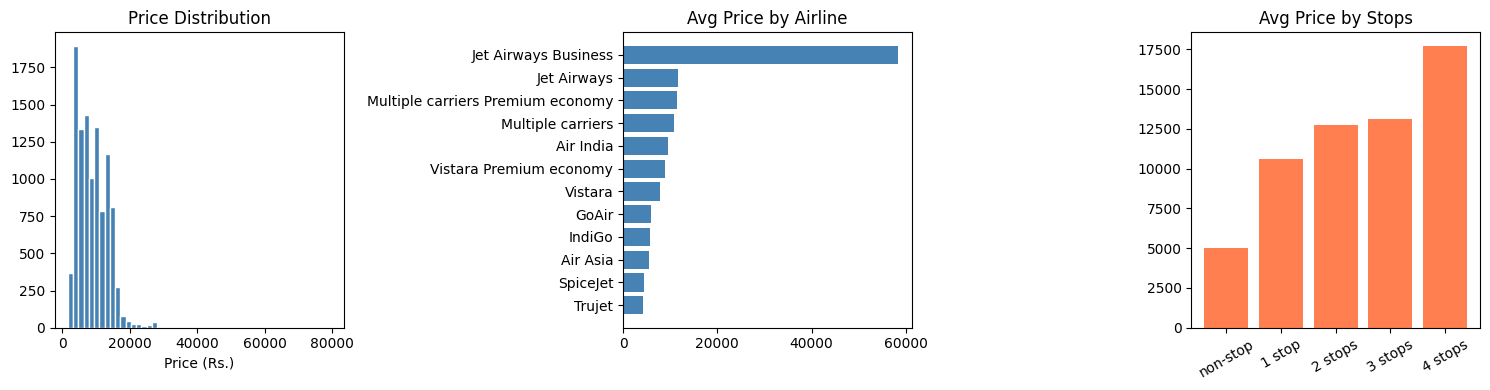

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (Rs.)")

avg = df.groupby('Airline')['Price'].mean().sort_values()
axes[1].barh(avg.index, avg.values, color='steelblue')
axes[1].set_title("Avg Price by Airline")

stop_avg = df.groupby('Total_Stops')['Price'].mean().sort_values()
axes[2].bar(stop_avg.index, stop_avg.values, color='coral')
axes[2].set_title("Avg Price by Stops")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 3. CLEANING AND PREPARING DATA

In [9]:

df.dropna(inplace=True)

def to_mins(x):
    h = int(x.split('h')[0]) if 'h' in x else 0
    m = int(x.split('h')[1].replace('m','').strip()) if 'h' in x and 'm' in x else (int(x.replace('m','')) if 'm' in x else 0)
    return h*60 + m

df['Duration_Mins'] = df['Duration'].apply(to_mins)

df['Stops'] = df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4})

df['Dep_Hour'] = df['Dep_Time'].apply(lambda x: int(x.split(':')[0]))

df['Month'] = pd.to_datetime(df['Date_of_Journey'], dayfirst=True).dt.month

le = LabelEncoder()
df['Airline_N']     = le.fit_transform(df['Airline'])
df['Source_N']      = le.fit_transform(df['Source'])
df['Dest_N']        = le.fit_transform(df['Destination'])

df['Target'] = (df['Price'] > df['Price'].median()).astype(int)

print("Data prepared!")
print("Low Fare flights  :", (df['Target']==0).sum())
print("High Fare flights :", (df['Target']==1).sum())

Data prepared!
Low Fare flights  : 5369
High Fare flights : 5313


### 4. TRAINING THE MODEL

In [10]:
X = df[['Airline_N','Source_N','Dest_N','Duration_Mins','Stops','Dep_Hour','Month']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained!")
print("Train rows:", len(X_train), " | Test rows:", len(X_test))


Model trained!
Train rows: 8545  | Test rows: 2137


### 5. CHECKING MODEL ACCURACY

In [11]:
y_pred = model.predict(X_test)

print("Training Accuracy :", round(accuracy_score(y_train, model.predict(X_train))*100, 2), "%")
print("Testing  Accuracy :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("AUC Score         :", round(roc_auc_score(y_test, model.predict_proba(X_test)[:,1]), 4))
print()
print(classification_report(y_test, y_pred, target_names=['Low Fare','High Fare']))

Training Accuracy : 83.05 %
Testing  Accuracy : 84.84 %
AUC Score         : 0.91

              precision    recall  f1-score   support

    Low Fare       0.89      0.78      0.84      1052
   High Fare       0.81      0.91      0.86      1085

    accuracy                           0.85      2137
   macro avg       0.85      0.85      0.85      2137
weighted avg       0.85      0.85      0.85      2137



### 6. CONFUSION MATRIX

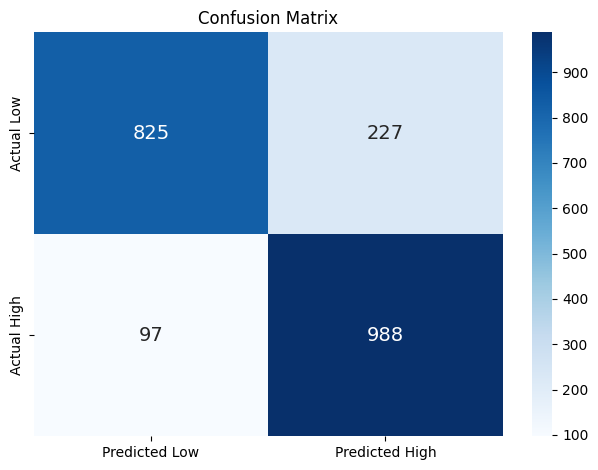

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low','Predicted High'],
            yticklabels=['Actual Low','Actual High'],
            annot_kws={'size':14})
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

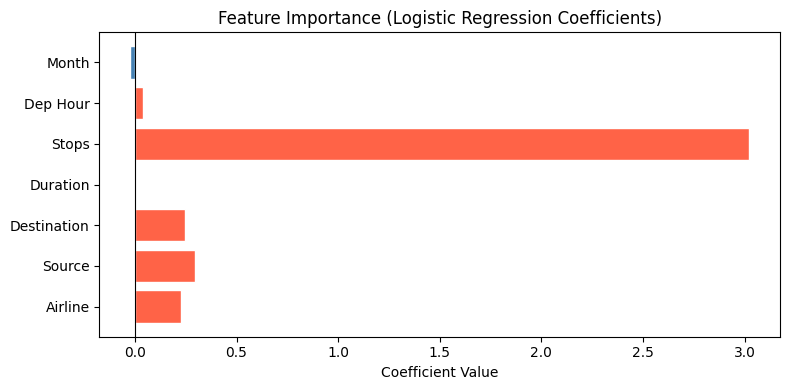

In [13]:
features = ['Airline','Source','Destination','Duration','Stops','Dep Hour','Month']
coefs    = model.coef_[0]
colors   = ['tomato' if c > 0 else 'steelblue' for c in coefs]

plt.figure(figsize=(8, 4))
plt.barh(features, coefs, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


### 7. PREDICT A NEW FLIGHT

In [14]:
new = pd.DataFrame([[3, 0, 3, 170, 0, 6, 5]],
                   columns=['Airline_N','Source_N','Dest_N','Duration_Mins','Stops','Dep_Hour','Month'])

result     = model.predict(new)[0]
confidence = model.predict_proba(new)[0][result] * 100

print("Prediction :", "HIGH FARE (Expensive)" if result == 1 else "LOW FARE (Affordable)")
print("Confidence :", round(confidence, 1), "%")

Prediction : LOW FARE (Affordable)
Confidence : 98.2 %
